## Requirements


(150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
               Id  SepalLe

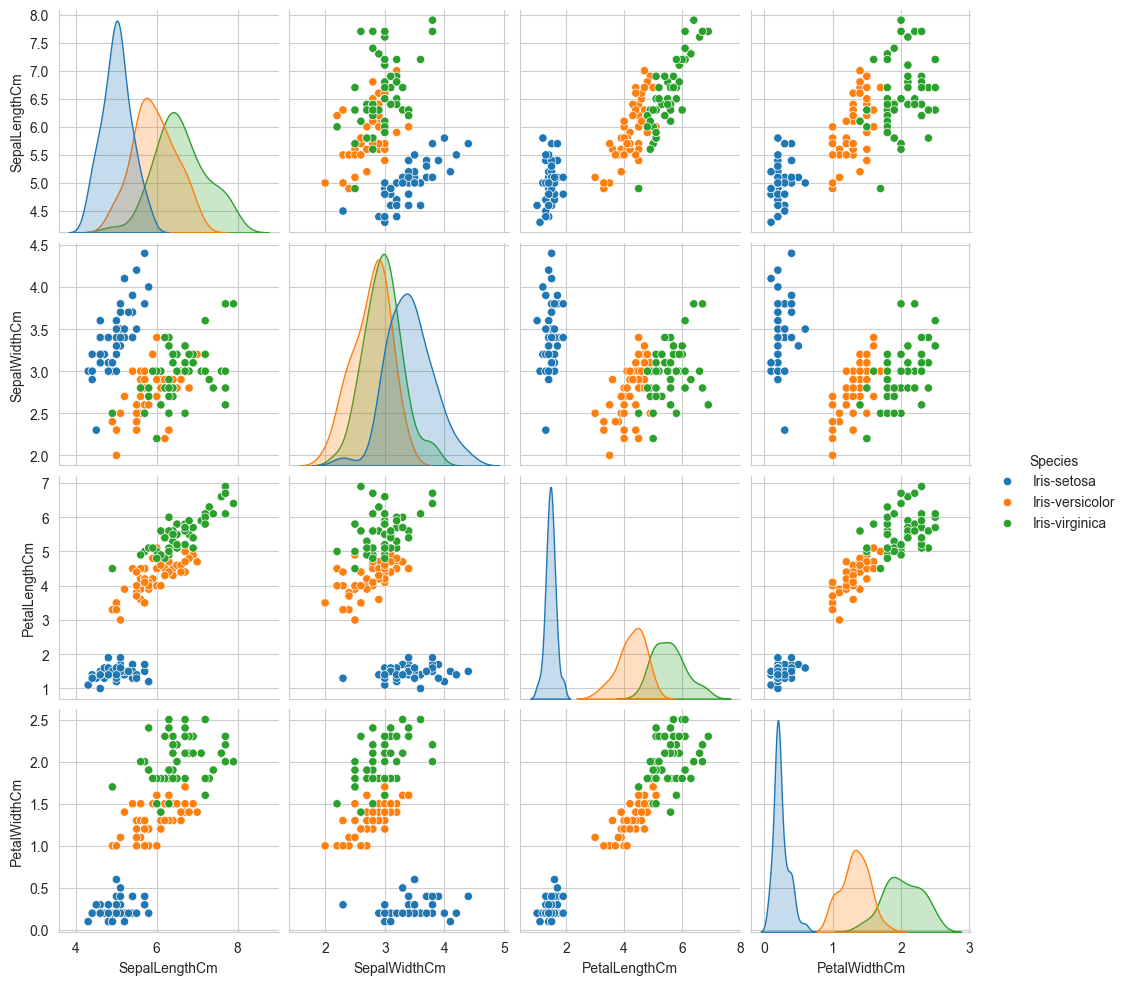

In [1]:

import pandas as pd 
import numpy as np  

import matplotlib.pyplot as plt  
import seaborn as sns            


%matplotlib inline
sns.set_style('whitegrid')  

df = pd.read_csv('Iris.csv')

print(df.shape)
print(df.head())

df.info()

print(df.describe())

print(df['Species'].value_counts())

sns.pairplot(df, hue='Species', vars=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
plt.show()

1. Contains 5 columns including column with class division
2. Mean is quiet variable, needs to be scaled
3. No Nan - cells
4. Class balace is 1:1:1
5. Dataset is tiny, which can give unstable results


## EDA


In [2]:
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler      

X = df.drop(['Id', 'Species'], axis=1) 
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(X_train.describe().loc[['mean', 'std']]) 

print(X_train_scaled.describe().loc[['mean', 'std']])

print(X_test_scaled.describe().loc[['mean', 'std']])

      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean       5.841667      3.044167       3.770833      1.204167
std        0.840926      0.445669       1.767417      0.763825
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean  -1.369275e-16  4.551914e-16  -9.066821e-17  5.366078e-17
std    1.004193e+00  1.004193e+00   1.004193e+00  1.004193e+00
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean       0.009951      0.110784      -0.034564     -0.036154
std        0.941190      0.869521       1.012241      1.016412


1. Optimaly divide train/test in 4:1 ratio
2. Scale our dataframe because for KNN we need all our signs need all our signes in one order to properly calculate distance between them, which is basically what this method uses as its logic
3. We necesserily fit our scaler on  X_train because if we train in X_test we basically give answers to our model for the test we about to give it  

## KNN


k =  1 | 1.000 |  0.967
k =  3 | 0.958 |  0.933
k =  5 | 0.975 |  0.933
k =  7 | 0.975 |  0.967
k = 10 | 0.958 |  0.967
k = 15 | 0.967 |  0.967
k = 20 | 0.958 |  0.967
k = 25 | 0.958 |  0.900
k = 30 | 0.917 |  0.867
k = 35 | 0.875 |  0.867
k = 40 | 0.892 |  0.867
k = 45 | 0.892 |  0.867
k = 50 | 0.883 |  0.833


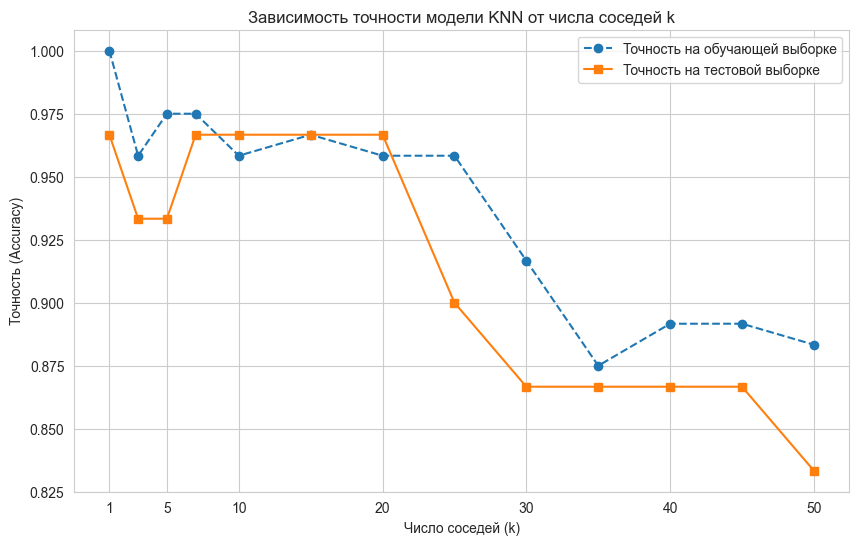

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

k_values = [1, 3, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 50]
train_accuracies = []
test_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    # Делаем предсказания для обучающей и тестовой выборок
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Считаем точность (accuracy)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"k = {k:2d} | {train_acc:.3f} |  {test_acc:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, marker='o', label='Точность на обучающей выборке', linestyle='--')
plt.plot(k_values, test_accuracies, marker='s', label='Точность на тестовой выборке', linestyle='-')
plt.xlabel('Число соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.title('Зависимость точности модели KNN от числа соседей k')
plt.xticks(k_values[::2])  # Показываем каждый второй k для читаемости
plt.legend()
plt.grid(True)
plt.show()

We try different k-number in order to avoid under/overeducation of our model 

## Cross-Validation


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline # Pipeline поможет нам не забыть про масштабирование

pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('knn', KNeighborsClassifier()) 
])

param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 10, 15, 20, 25, 30],  
    'knn__weights': ['uniform', 'distance'],                
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']  
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1) 

grid_search.fit(X_train, y_train)

print(f"Best: {grid_search.best_params_}")
print(f"Best accyracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
test_accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best model test score: {test_accuracy_best:.4f}")

print(classification_report(y_test, y_pred_best, target_names=y.unique()))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best: {'knn__metric': 'euclidean', 'knn__n_neighbors': 20, 'knn__weights': 'distance'}
Best accyracy: 0.9750
Best model test score: 0.9667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



This method uses a simple algorythm which sorts through all parametrs that we gave in param_grid, teaches model based on all of them and then gives statistics on which is the best


## Things to be aware of:

1. Results with and without scaling can dramatically differ
2. KNN model efficiency drastically depends on k-number and also can differ based on metrics
3. Dont neglect cross-validation. Its a powerful tool to choose best hyperparameters for your model
4. KNN works best on small dataframes with numeric signs

*Bonus: our results are more than likely to be unstable via small amount of information
 